In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv("/kaggle/input/fare-amount/final_internship_data.csv")

In [15]:
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [19]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour


In [20]:
print(len(df["User Name"].unique()))

221675


In [21]:
print(len(df["Driver Name"].unique()))

221700


In [22]:
print(df.isnull().sum())

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [24]:
df.dropna(inplace=True)

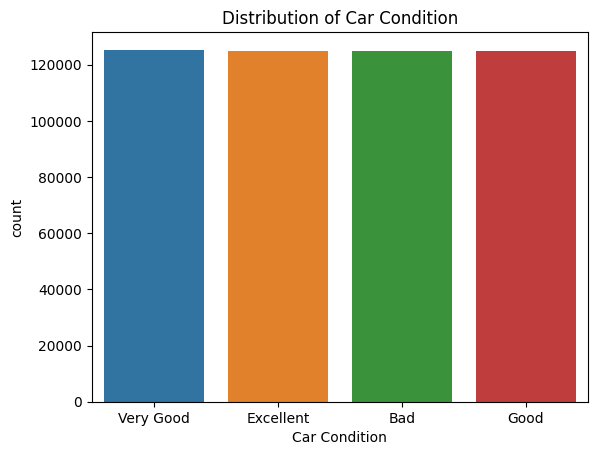

In [25]:
sns.countplot(x="Car Condition", data=df)
plt.title("Distribution of Car Condition")
plt.show()

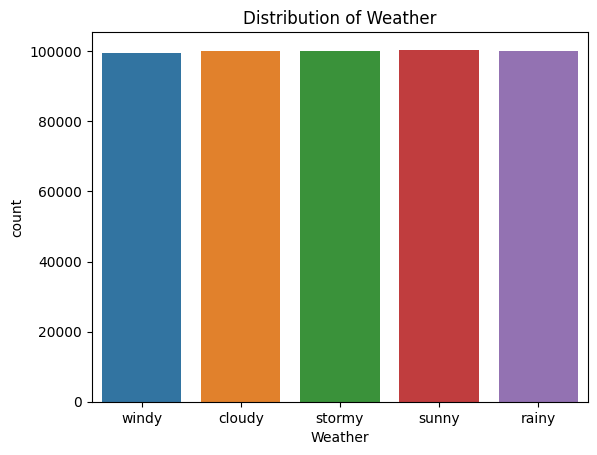

In [26]:
sns.countplot(x="Weather", data=df)
plt.title("Distribution of Weather")
plt.show()

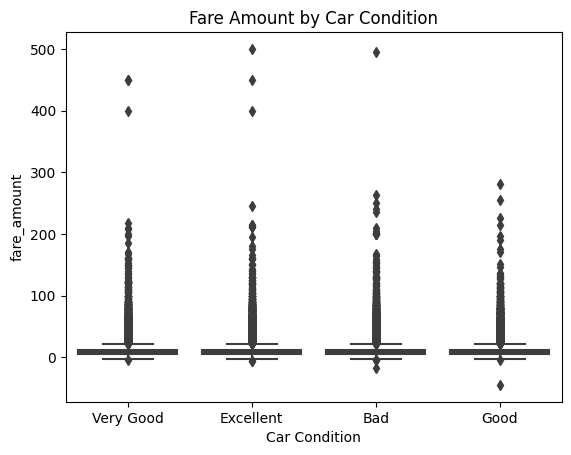

In [31]:
sns.boxplot(x="Car Condition", y="fare_amount", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

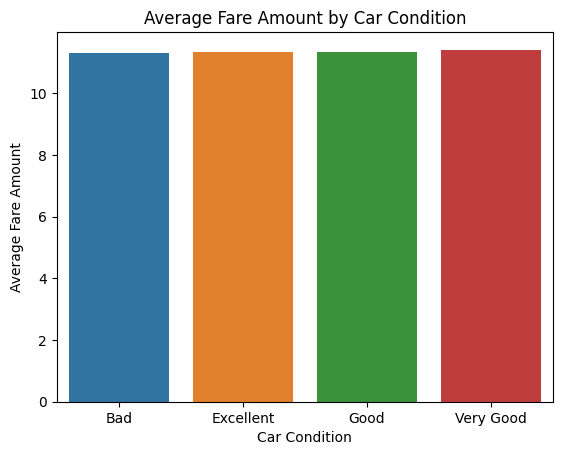

In [34]:
mean_fare = df.groupby("Car Condition")["fare_amount"].mean().reset_index()

sns.barplot(x="Car Condition", y="fare_amount", data=mean_fare)
plt.title("Average Fare Amount by Car Condition")
plt.xlabel("Car Condition")
plt.ylabel("Average Fare Amount")
plt.show()


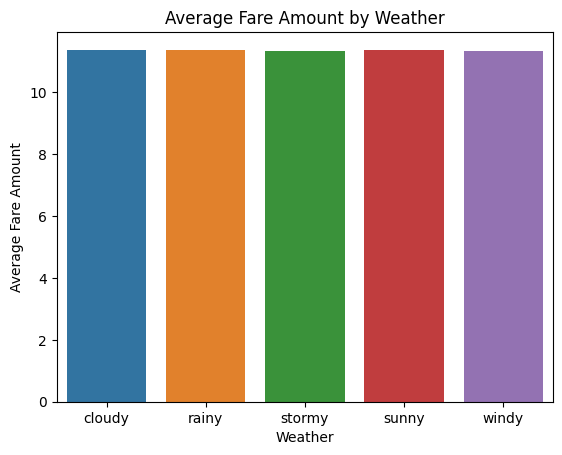

In [35]:
mean_fare = df.groupby("Weather")["fare_amount"].mean().reset_index()

sns.barplot(x="Weather", y="fare_amount", data=mean_fare)
plt.title("Average Fare Amount by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Fare Amount")
plt.show()


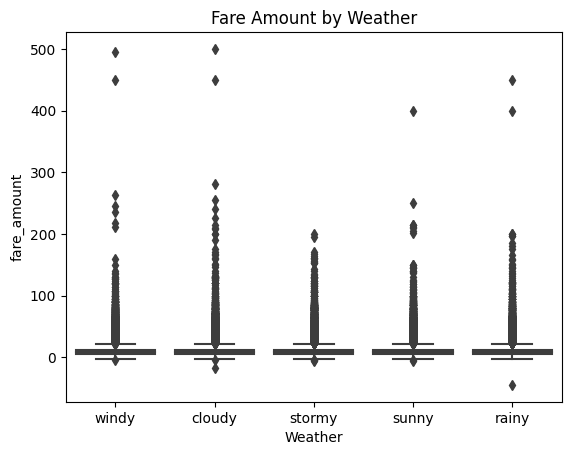

In [36]:
sns.boxplot(x="Weather", y="fare_amount", data=df)
plt.title("Fare Amount by Weather")
plt.show()

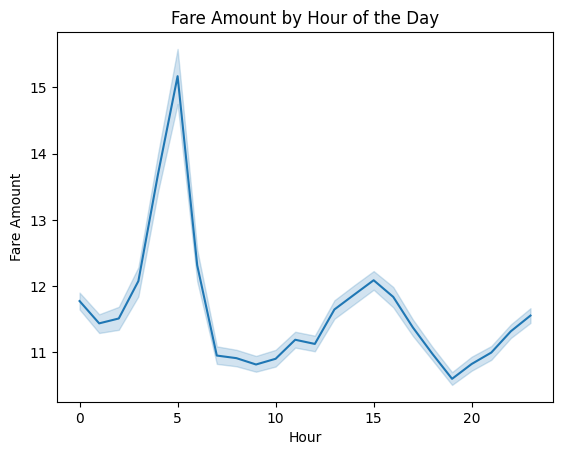

In [39]:
sns.lineplot(x="hour", y="fare_amount", data=df)
plt.title("Fare Amount by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Fare Amount")
plt.show()


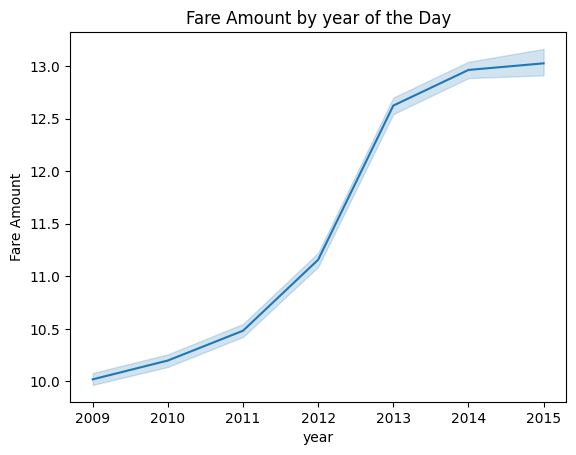

In [40]:
sns.lineplot(x="year", y="fare_amount", data=df)
plt.title("Fare Amount by year of the Day")
plt.xlabel("year")
plt.ylabel("Fare Amount")
plt.show()

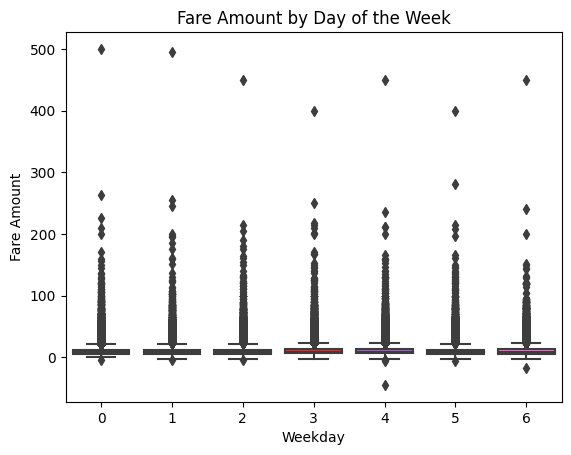

In [42]:
sns.boxplot(x="weekday", y="fare_amount", data=df)
plt.title("Fare Amount by Day of the Week")
plt.xlabel("Weekday")
plt.ylabel("Fare Amount")
plt.show()


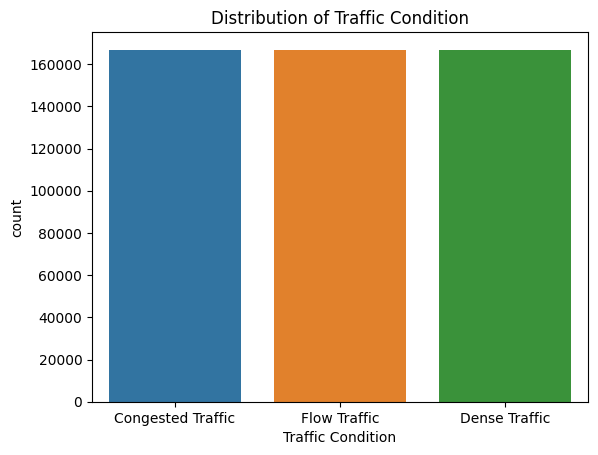

In [44]:
sns.countplot(x="Traffic Condition", data=df)
plt.title("Distribution of Traffic Condition")
plt.show()

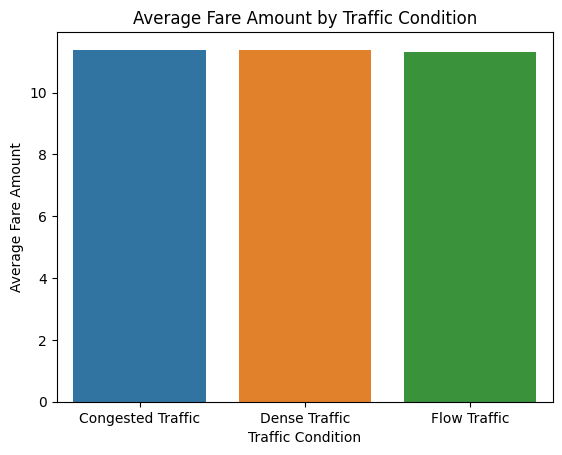

In [43]:
mean_fare = df.groupby("Traffic Condition")["fare_amount"].mean().reset_index()

sns.barplot(x="Traffic Condition", y="fare_amount", data=mean_fare)
plt.title("Average Fare Amount by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Fare Amount")
plt.show()

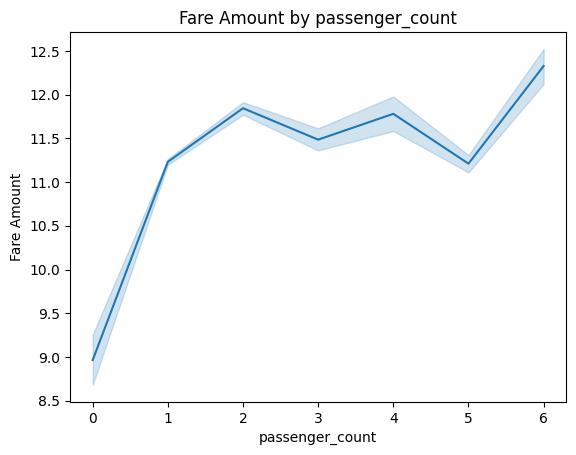

In [45]:
sns.lineplot(x="passenger_count", y="fare_amount", data=df)
plt.title("Fare Amount by passenger_count")
plt.xlabel("passenger_count")
plt.ylabel("Fare Amount")
plt.show()

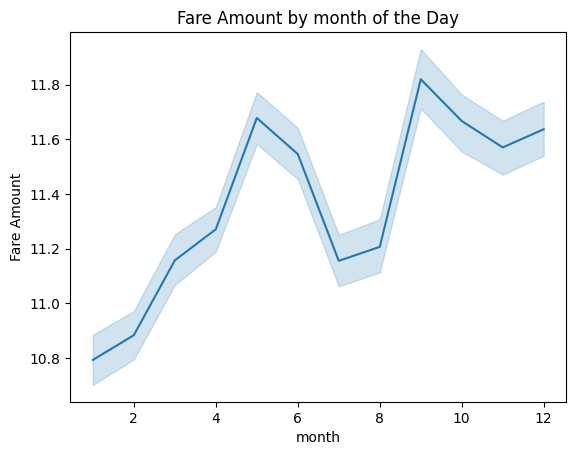

In [49]:
sns.lineplot(x="month", y="fare_amount", data=df)
plt.title("Fare Amount by month of the Day")
plt.xlabel("month")
plt.ylabel("Fare Amount")
plt.show()

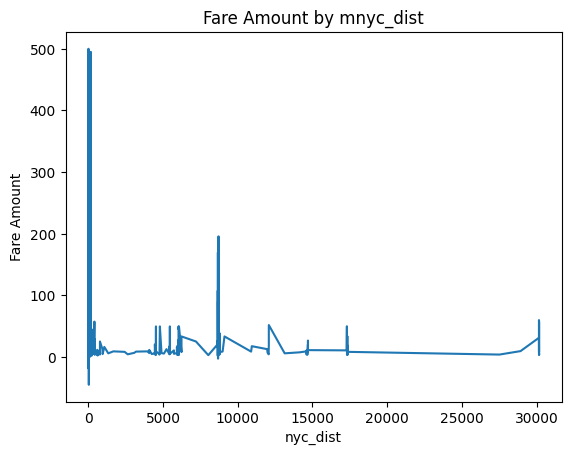

In [55]:
sns.lineplot(x="nyc_dist", y="fare_amount", data=df)
plt.title("Fare Amount by mnyc_dist")
plt.xlabel("nyc_dist")
plt.ylabel("Fare Amount")
plt.show()

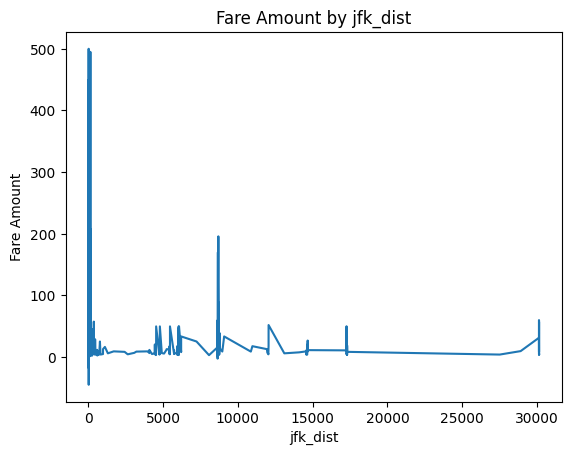

In [59]:
sns.lineplot(x="jfk_dist", y="fare_amount", data=df)
plt.title("Fare Amount by jfk_dist")
plt.xlabel("jfk_dist")
plt.ylabel("Fare Amount")
plt.show()

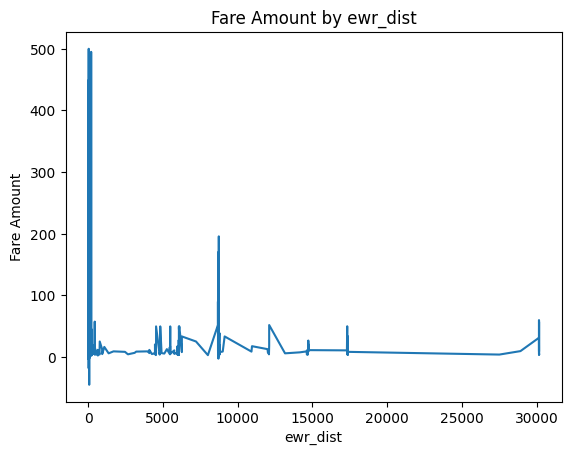

In [60]:
sns.lineplot(x="ewr_dist", y="fare_amount", data=df)
plt.title("Fare Amount by ewr_dist")
plt.xlabel("ewr_dist")
plt.ylabel("Fare Amount")
plt.show()

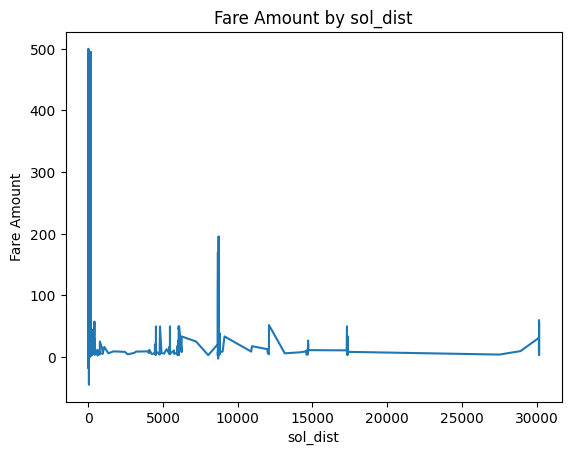

In [61]:
sns.lineplot(x="sol_dist", y="fare_amount", data=df)
plt.title("Fare Amount by sol_dist")
plt.xlabel("sol_dist")
plt.ylabel("Fare Amount")
plt.show()

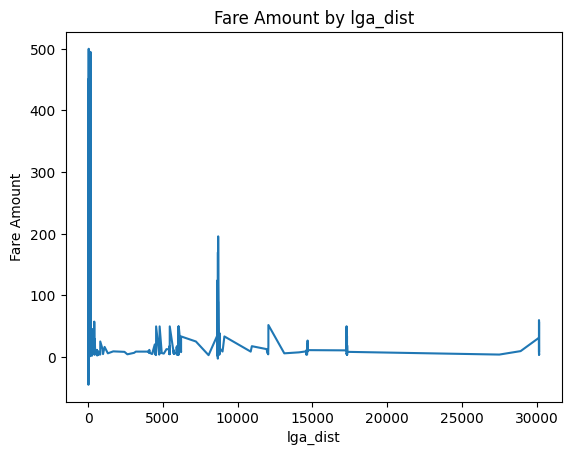

In [62]:
sns.lineplot(x="lga_dist", y="fare_amount", data=df)
plt.title("Fare Amount by lga_dist")
plt.xlabel("lga_dist")
plt.ylabel("Fare Amount")
plt.show()

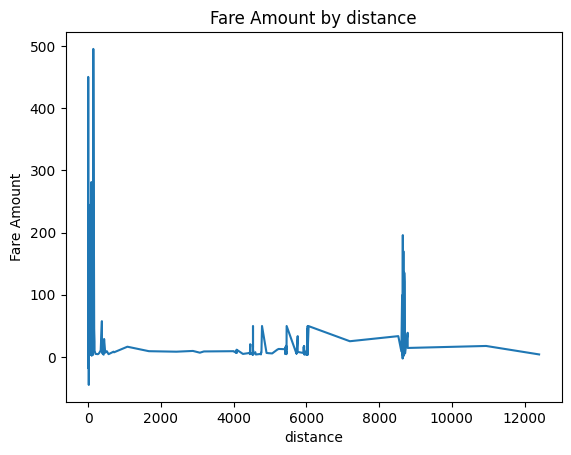

In [63]:
sns.lineplot(x="distance", y="fare_amount", data=df)
plt.title("Fare Amount by distance")
plt.xlabel("distance")
plt.ylabel("Fare Amount")
plt.show()

In [69]:
total_fare = df.groupby("Driver Name")["fare_amount"].sum()
top_10_fares = total_fare.nlargest(10)
print(top_10_fares)

Driver Name
Michael Smith        2868.51
David Smith          2116.96
Michael Johnson      2059.79
Christopher Smith    1980.91
Michael Williams     1896.37
Robert Smith         1828.61
James Smith          1708.78
John Smith           1694.36
Michael Jones        1662.08
Jennifer Smith       1586.90
Name: fare_amount, dtype: float64


In [71]:
less_10_fares = total_fare.nsmallest(10)
print(less_10_fares)

Driver Name
Scott Watkins          -12.4
Kristin Roberts        -12.2
Randy Wilson DDS        -6.5
Theresa Hogan           -5.0
Aimee Duran             -3.0
Miss Susan Greer        -2.5
Charles Kelly DVM        0.0
Kathy Fleming            0.0
Mrs. Stephanie Black     0.0
Shaun Rogers             2.3
Name: fare_amount, dtype: float64


In [73]:
df["fare_amount"].min()

-44.9

In [74]:
df["fare_amount"].max()

500.0

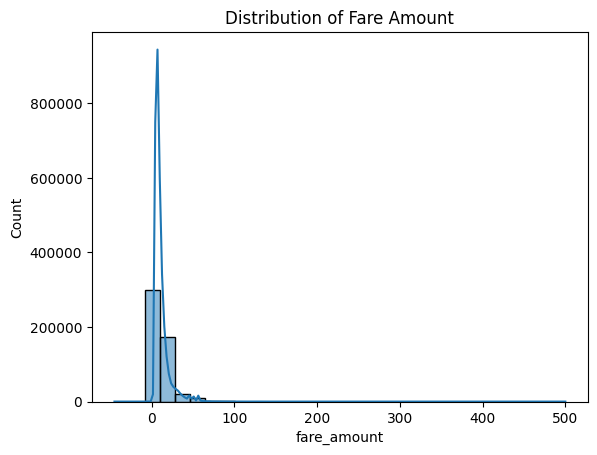

In [75]:
sns.histplot(df["fare_amount"], bins=30, kde=True)
plt.title("Distribution of Fare Amount")
plt.show()

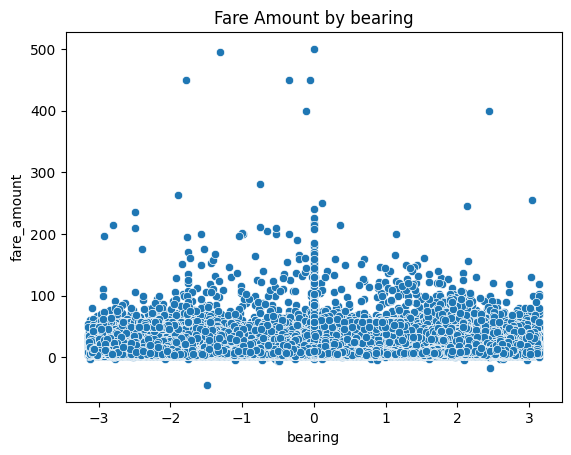

In [80]:
sns.scatterplot(x="bearing", y="fare_amount", data=df)
plt.title("Fare Amount by bearing")
plt.show()

In [82]:
michael_cars = df[df["Driver Name"] == "Michael Smith"]["Car Condition"].unique()
print("Car Conditions for Michael Smith:", michael_cars)

Car Conditions for Michael Smith: ['Good' 'Excellent' 'Bad' 'Very Good']


In [92]:
michael_years = df[df["Driver Name"] == "Michael Smith"]["year"].unique()
print("year for Michael Smith:", michael_years)

year for Michael Smith: [2014 2009 2012 2013 2011 2010 2015]


In [89]:
David_cars = df[df["Driver Name"] == "David Smith"]["Car Condition"].unique()
print("Car Conditions for David Smith:", David_cars)

Car Conditions for David Smith: ['Excellent' 'Good' 'Very Good' 'Bad']


In [93]:
David_years = df[df["Driver Name"] == "David Smith"]["year"].unique()
print("year for David Smith:", David_years)

year for David Smith: [2012 2009 2015 2010 2014 2013 2011]


In [90]:
Scott_cars = df[df["Driver Name"] == "Scott Watkins"]["Car Condition"].unique()
print("Car Conditions for Scott Watkins:", Scott_cars)

Car Conditions for Scott Watkins: ['Bad' 'Excellent']


In [94]:
Scott_years = df[df["Driver Name"] == "Scott Watkins"]["year"].unique()
print("year for Scott Watkins:", Scott_years)

year for Scott Watkins: [2010 2011]


In [91]:
Kristin_cars = df[df["Driver Name"] == "Kristin Roberts"]["Car Condition"].unique()
print("Car Conditions for Scott Watkins:", Kristin_cars)

Car Conditions for Scott Watkins: ['Good' 'Bad' 'Excellent']


In [96]:
Kristin_years = df[df["Driver Name"] == "Kristin Roberts"]["year"].unique()
print("years for Scott Watkins:", Kristin_years)

years for Scott Watkins: [2010 2009 2011]


In [97]:
drivers_per_year = df.groupby("year")["Driver Name"].nunique()
print(drivers_per_year)


year
2009    57681
2010    56836
2011    59384
2012    59537
2013    58295
2014    56418
2015    29303
Name: Driver Name, dtype: int64


In [ ]:
total_fare = df.groupby("Driver Name")["fare_amount"].sum()

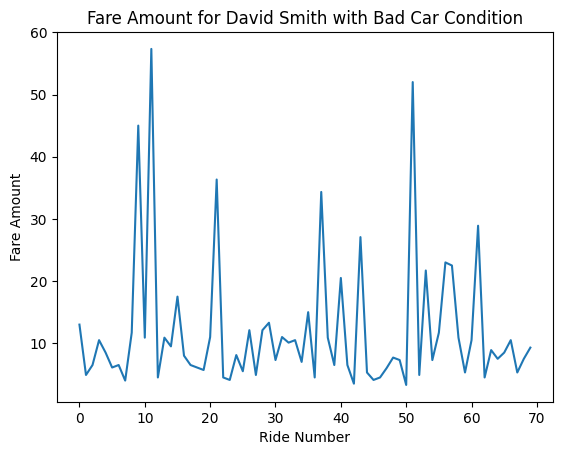

In [85]:
david_bad_car = df[(df["Driver Name"] == "Michael Smith") & (df["Car Condition"] == "Bad")]

# Reset index to use it as the x-axis for the line plot
david_bad_car = david_bad_car.reset_index()
sns.lineplot(x=david_bad_car.index, y="fare_amount", data=david_bad_car)
plt.title("Fare Amount for David Smith with Bad Car Condition")
plt.xlabel("Ride Number")
plt.ylabel("Fare Amount")
plt.show()

In [101]:
data_2015 = df[df["year"] == 2015]
fare_by_driver = data_2015.groupby("Driver Name")["fare_amount"].sum()
top_5_drivers = fare_by_driver.sort_values(ascending=False).head(5)
print(top_5_drivers)


Driver Name
Melissa Delgado    495.00
Benjamin Mason     461.00
William Smith      246.41
Melvin Weber       245.41
Mary Howard        235.00
Name: fare_amount, dtype: float64
